In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def incarca_si_exploreaza_date():
    df = pd.read_csv('data/surveyDataSience.csv', low_memory=False)
    intrebari = df.iloc[0]
    df = df.iloc[1:].reset_index(drop=True)
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except ValueError:
            pass
    return df

df_survey = incarca_si_exploreaza_date()

nr_respondenti = len(df_survey)
print(f'Numarul total de respondenti: {nr_respondenti}')

Numarul total de respondenti: 25973


In [4]:
nr_atribute = len(df_survey.columns)
print(f'Numarul total de atribute: {nr_atribute}')

tipuri_date = df_survey.dtypes.value_counts()
print(f"Numar de atribute per respondent: {tipuri_date}")

Numarul total de atribute: 369
Numar de atribute per respondent: str        338
float64     30
int64        1
Name: count, dtype: int64


In [5]:
intrebari_unice = set(col.split('_')[0] for col in df_survey.columns if col.startswith('Q'))
respondenti_valizi = pd.Series(True, index=df_survey.index)
for q in intrebari_unice:
    coloane_q = [col for col in df_survey.columns if col == q or col.startswith(q + '_')]
    a_raspuns = df_survey[coloane_q].notna().any(axis=1)
    respondenti_valizi &= a_raspuns

nr_respondenti_completi = respondenti_valizi.sum()
print(f"Numarul de respondenti pentru care se detin date complete: {nr_respondenti_completi}")

Numarul de respondenti pentru care se detin date complete: 201


In [6]:

durata_educatie = {
    "Bachelor’s degree": 3,
    "Master’s degree": 5,
    "Doctoral degree": 8,
    "Professional doctorate": 8,
}

df_survey['Durata_educatie'] = df_survey['Q4'].map(durata_educatie)
media_totala = df_survey['Durata_educatie'].mean()

df_romania = df_survey[df_survey['Q3'] == 'Romania']
media_romania = df_romania['Durata_educatie'].mean()

df_ro_femei = df_romania[df_romania['Q2'] == 'Woman']
media_ro_femei = df_ro_femei['Durata_educatie'].mean()

print(f"Durata medie in Romania: {media_romania}")
print(f"Durata medie femei din Romania: {media_ro_femei}")
print(f"Durata medie totala: {media_totala}")

Durata medie in Romania: 5.245283018867925
Durata medie femei din Romania: 5.6
Durata medie totala: 4.553807019056652


In [7]:
nr_femei_ro_complete = df_ro_femei[respondenti_valizi[df_ro_femei.index]].shape[0]
print(f"Numarul de femei din Romania pentru care se detin date complete: {nr_femei_ro_complete}")

Numarul de femei din Romania pentru care se detin date complete: 0


In [8]:
col_varsta = 'Q1'
col_python = 'Q7_Part_1'
col_cpp = 'Q7_Part_5'

df_femei_python = df_ro_femei[df_ro_femei[col_python].notna()]
nr_femei_python = len(df_femei_python)

if(nr_femei_python > 0):
    varsta_predominanta_python = df_femei_python[col_varsta].value_counts().idxmax()
else:
    varsta_predominanta_python = "N/A"

df_femei_cpp = df_ro_femei[df_ro_femei[col_cpp].notna()]
nr_femei_cpp = len(df_femei_cpp)

if(nr_femei_cpp > 0):
    varsta_predominanta_cpp = df_femei_cpp[col_varsta].value_counts().idxmax()
else:
    varsta_predominanta_cpp = "N/A"

print("\n-- Varsta predominanta pentru femeile din Romania care folosesc Python vs C++ --")
print(f"Numar femei care folosesc Python: {nr_femei_python}")
print(f"Intervalul de varsta predominant pentru femeile care folosesc Python: {varsta_predominanta_python}")
print(f"Numar femei care folosesc C++: {nr_femei_cpp}")
print(f"Intervalul de varsta predominant pentru femeile care folosesc C++: {varsta_predominanta_cpp}")



-- Varsta predominanta pentru femeile din Romania care folosesc Python vs C++ --
Numar femei care folosesc Python: 12
Intervalul de varsta predominant pentru femeile care folosesc Python: 35-39
Numar femei care folosesc C++: 4
Intervalul de varsta predominant pentru femeile care folosesc C++: 18-21


In [9]:
print("\n-- Analiza primelor 5 coloane --")
for col in df_survey.columns[:5]:
    if pd.api.types.is_numeric_dtype(df_survey[col]):
        minim = df_survey[col].min()
        maxim = df_survey[col].max()
        print(f"Coloana: {col} - Min: {minim}, Max: {maxim}")
    else:
        nr_valori_unice = df_survey[col].nunique()
        valori_extreme = df_survey[col].dropna().unique()[:5].tolist()
        print(f"Coloana: {col} - Numar valori unice: {nr_valori_unice}, Valori extreme: {valori_extreme}")        


-- Analiza primelor 5 coloane --
Coloana: Time from Start to Finish (seconds) - Min: 120, Max: 2488653
Coloana: Q1 - Numar valori unice: 11, Valori extreme: ['50-54', '22-24', '45-49', '25-29', '18-21']
Coloana: Q2 - Numar valori unice: 5, Valori extreme: ['Man', 'Woman', 'Nonbinary', 'Prefer not to say', 'Prefer to self-describe']
Coloana: Q3 - Numar valori unice: 66, Valori extreme: ['India', 'Indonesia', 'Pakistan', 'Mexico', 'Russia']
Coloana: Q4 - Numar valori unice: 7, Valori extreme: ['Bachelor’s degree', 'Master’s degree', 'Doctoral degree', 'I prefer not to answer', 'Some college/university study without earning a bachelor’s degree']


In [10]:
mapare_experienta = {
    'I have never written code': 0,
    '< 1 years': 0.5,
    '1-2 years': 1.5,
    '1-3 years': 2,
    '2-3 years': 2.5,
    '3-4 years': 3.5,
    '3-5 years': 4,
    '4-5 years': 4.5,
    '5-10 years': 7.5,
    '10-20 years': 15,
    '20+' : 25,
    '20+ years' : 25
}

df_survey['Experienta'] = df_survey['Q6'].map(mapare_experienta)
vechime = df_survey['Experienta'].dropna()

minim = vechime.min()
maxim = vechime.max()
media = vechime.mean()
deviatia_standard = vechime.std()
mediana = vechime.median()

print("\n-- Analiza experientei in programare --")
print(f"Vechimea minima: {minim} ani")
print(f"Vechimea maxima: {maxim} ani")
print(f"Vechimea medie: {media:.2f} ani")
print(f"Deviatia standard a vechimii: {deviatia_standard:.2f} ani")
print(f"Mediana vechimii: {mediana} ani")



-- Analiza experientei in programare --
Vechimea minima: 0.0 ani
Vechimea maxima: 25.0 ani
Vechimea medie: 5.28 ani
Deviatia standard a vechimii: 6.79 ani
Mediana vechimii: 2.0 ani


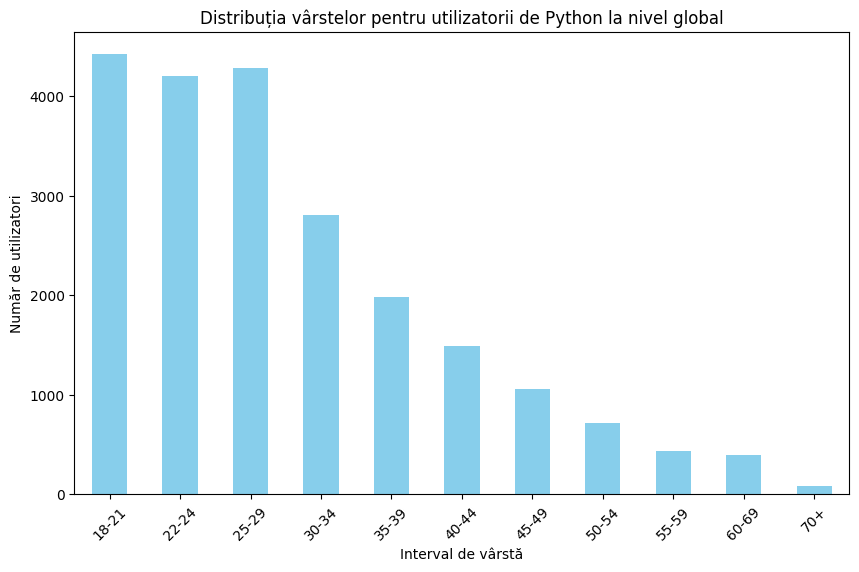

In [11]:
df_py_global = df_survey[df_survey['Q7_Part_1'].notna()]
dist_py_global = df_py_global['Q1'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
dist_py_global.plot(kind='bar', color='skyblue')
plt.title('Distribuția vârstelor pentru utilizatorii de Python la nivel global')
plt.xlabel('Interval de vârstă')
plt.ylabel('Număr de utilizatori')
plt.xticks(rotation=45)
plt.show()

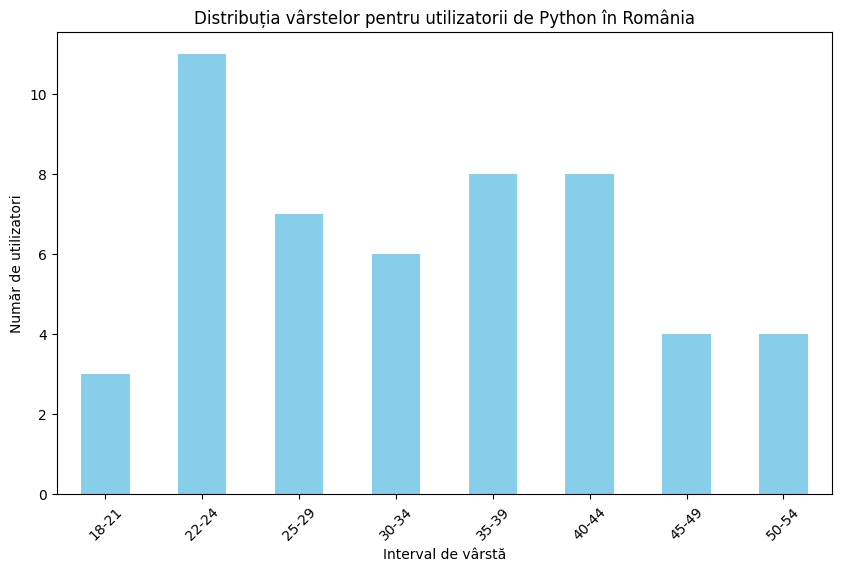

In [12]:
df_py_ro = df_survey[(df_survey['Q3'] == 'Romania') & (df_survey['Q7_Part_1'].notna())]
dist_py_ro = df_py_ro['Q1'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
dist_py_ro.plot(kind='bar', color='skyblue')
plt.title('Distribuția vârstelor pentru utilizatorii de Python în România')
plt.xlabel('Interval de vârstă')
plt.ylabel('Număr de utilizatori')
plt.xticks(rotation=45)
plt.show()


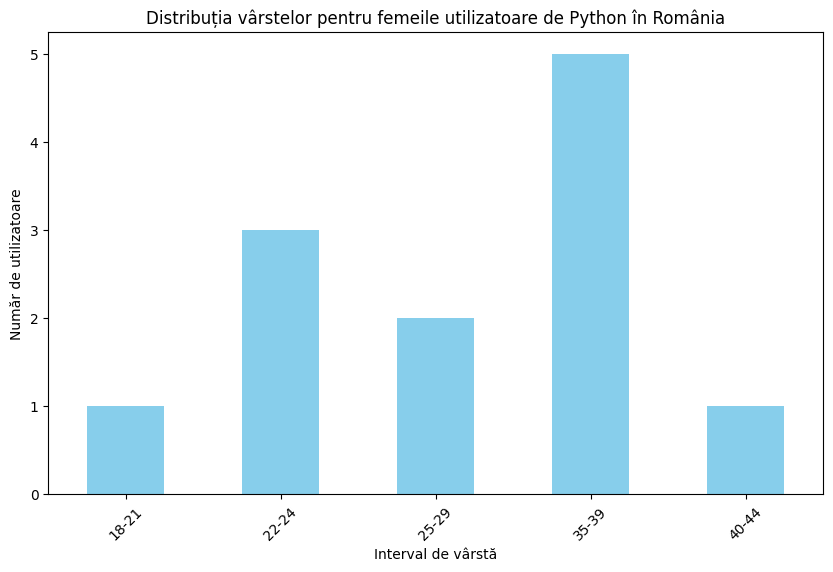

In [13]:
df_py_ro = df_survey[(df_survey['Q3'] == 'Romania') & (df_survey['Q7_Part_1'].notna()) & (df_survey['Q2'] == 'Woman')]
dist_py_ro = df_py_ro['Q1'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
dist_py_ro.plot(kind='bar', color='skyblue')
plt.title('Distribuția vârstelor pentru femeile utilizatoare de Python în România')
plt.xlabel('Interval de vârstă')
plt.ylabel('Număr de utilizatoare')
plt.xticks(rotation=45)
plt.show()

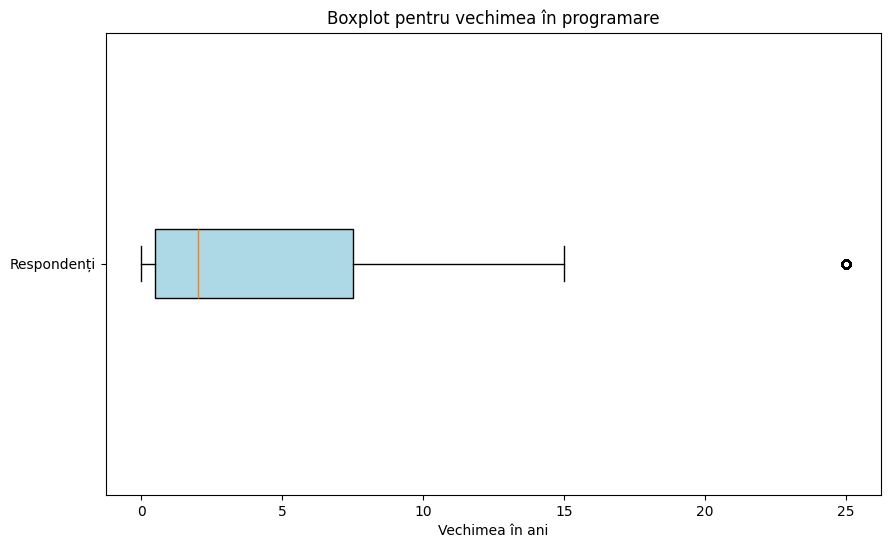

In [14]:
plt.figure(figsize=(10, 6))
plt.boxplot(vechime, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot pentru vechimea în programare')
plt.xlabel('Vechimea în ani')
plt.yticks([1], ['Respondenți'])
plt.show()

Normalizare

In [15]:
min_educatie = df_survey['Durata_educatie'].min()
max_educatie = df_survey['Durata_educatie'].max()

df_survey['Durata_educatie_normalizata'] = (df_survey['Durata_educatie'] - min_educatie) / (max_educatie - min_educatie)

print("Durata educatie normalizata:")
print(df_survey['Durata_educatie_normalizata'].dropna().head().to_string())

media_exp = df_survey['Experienta'].mean()
std_exp = df_survey['Experienta'].std()
df_survey['Experienta_normalizata'] = (df_survey['Experienta'] - media_exp) / std_exp

print("\nExperienta normalizata:")
print(df_survey['Experienta_normalizata'].dropna().head().to_string())

Durata educatie normalizata:
0    0.0
1    0.4
2    0.4
3    1.0
4    1.0

Experienta normalizata:
0    0.326752
1    2.903728
2   -0.483155
3    2.903728
4   -0.704039
